## Aufgabe 3: Induktiv gekoppelte Schwingkreise

### Ziel
Für zwei induktiv gekoppelte LC-Schwingkreise soll der Kopplungsgrad $k_L$ in Abhängigkeit vom Spulenabstand $d$ bestimmt werden. Dazu werden die Resonanzfrequenzen $f_+$ und $f_-$ aus den FFT-Spektren entnommen. Anschließend wird aus $k_L$ die Gegeninduktivität $M$ berechnet und $M(d)$ mit dem theoretischen Maxwell-Ausdruck verglichen. Wir haben den folgenden Schaltkreis für die Aufgabe genutzt:

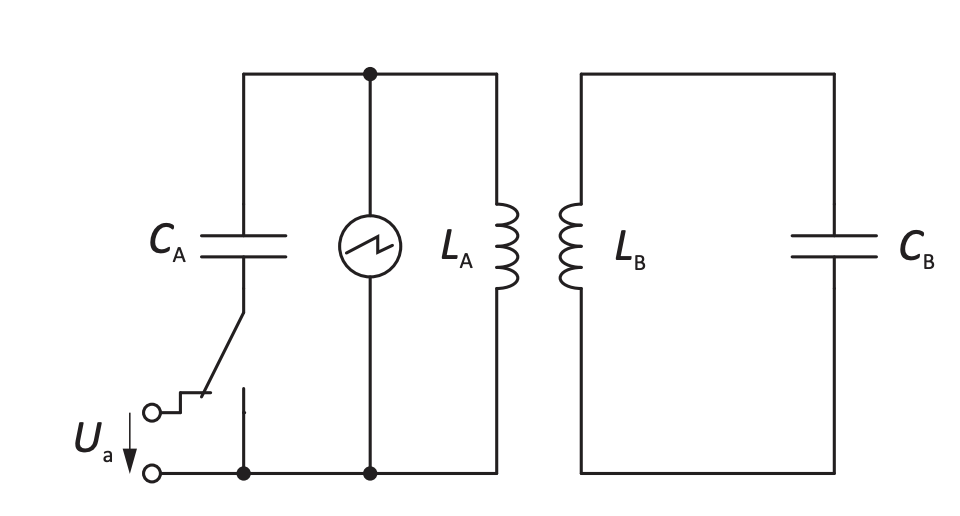


### Messprinzip: Warum entstehen zwei Peaks?
Bei induktiver Kopplung beeinflusst das Magnetfeld der einen Spule die andere. Mathematisch führt das auf gekoppelte Differentialgleichungen, die durch Bildung von
$$
I_+ = I_A + I_B,\quad I_- = I_A - I_B
$$
entkoppelt werden. Dadurch erhält man zwei Eigenmoden mit effektiven Induktivitäten $L+M$ (gleichsinnig) und $L-M$ (gegensinnig). Die zugehörigen Kreisfrequenzen lauten:
$$
\omega_+ = \frac{1}{\sqrt{C(L+M)}},\qquad
\omega_- = \frac{1}{\sqrt{C(L-M)}}
$$

Damit ist $\omega_+ < \omega_-$ und im FFT-Spektrum erscheinen zwei Resonanzpeaks bei $f_+ = \omega_+/(2\pi)$ und $f_- = \omega_-/(2\pi)$


### Bestimmung der Frequenzen aus den Spektren
Für jeden gemessenen Abstand $d$:

1. FFT-Spektrum aufnehmen und in einer gemeinsamen Abbildung darstellen (so wie bei Aufgabe 1).
2. Die beiden Resonanzfrequenzen bestimmen:
   - $f_+$: der kleinere Peak (gleichsinnige Mode),
   - $f_-$: der größere Peak (gegensinnige Mode).
3. Zusätzlich einmal die ungekoppelte Eigenfrequenz $f_0$ messen. Dafür haben wir bei uns $f_0 = 2.843 kHz$ herausbekommen.

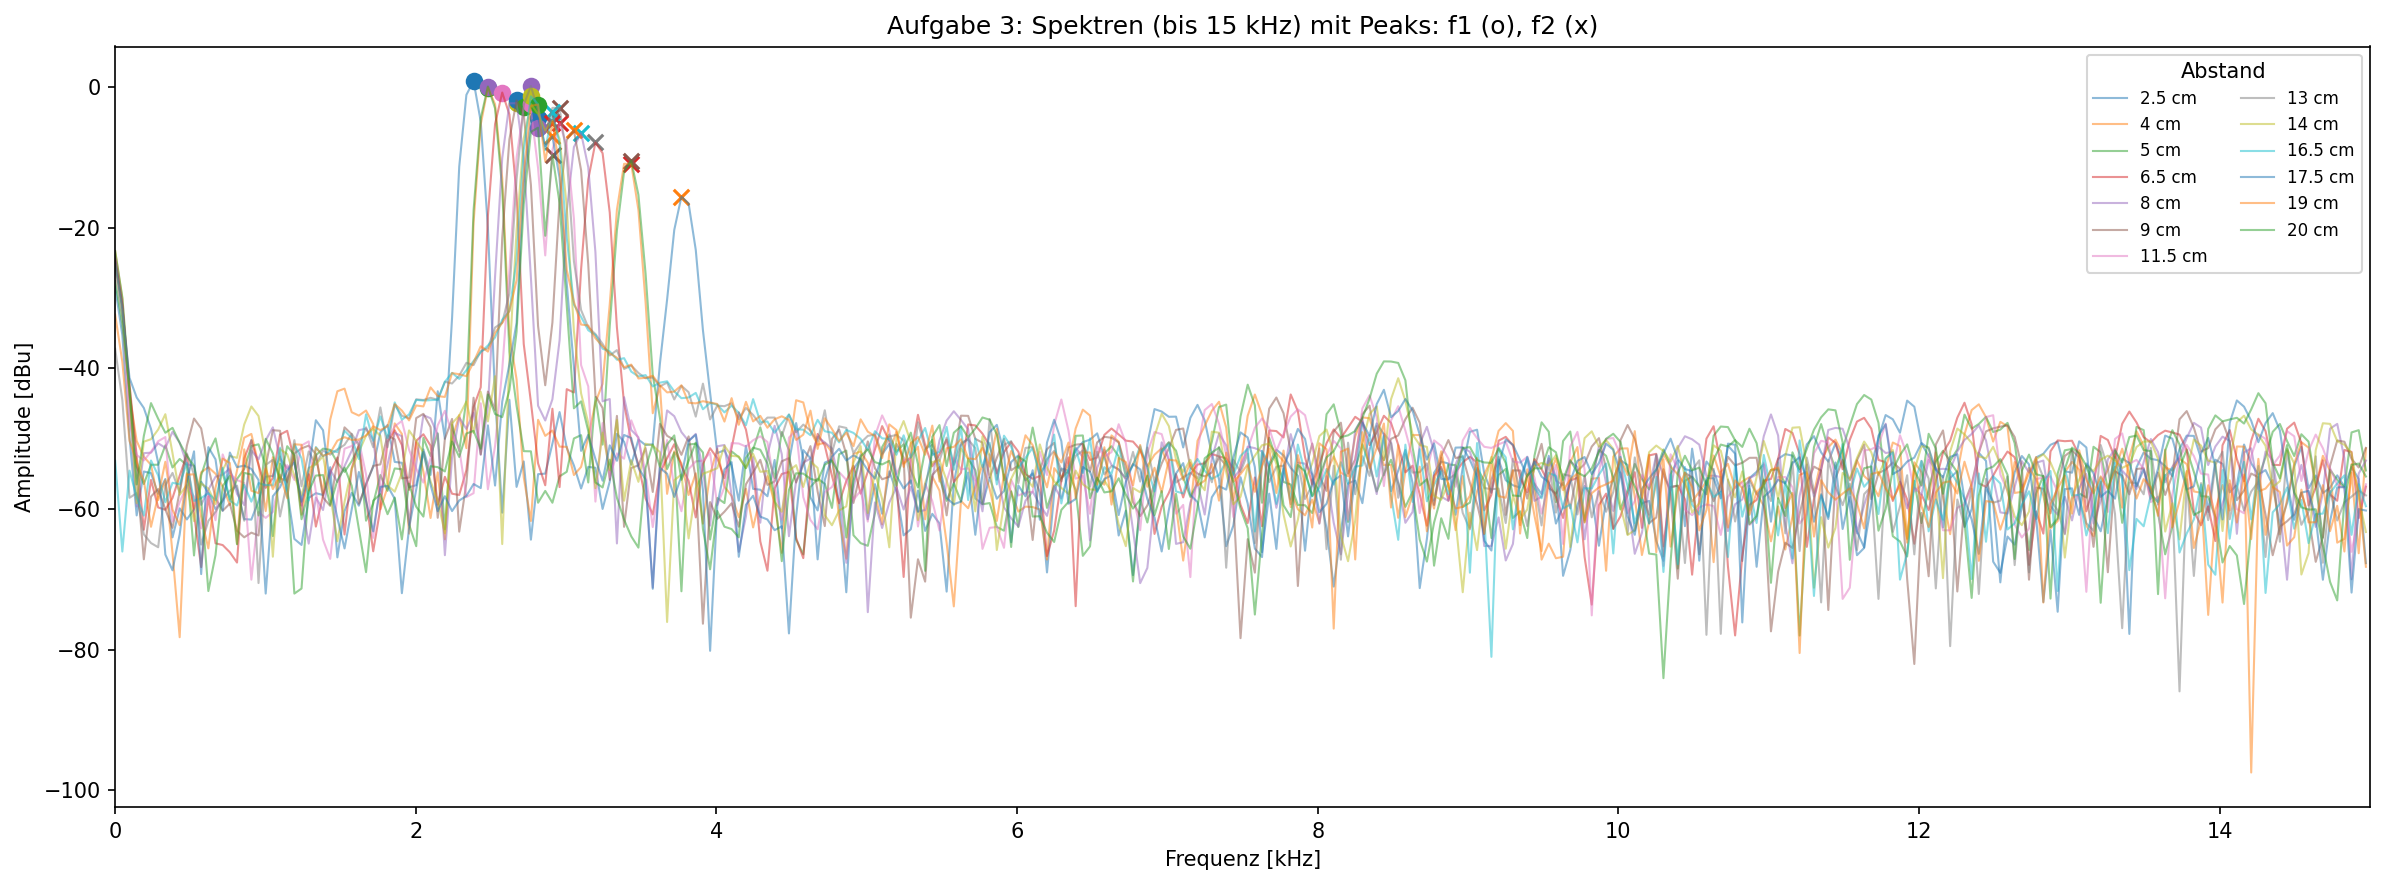


Gefundene Peaks:
 d_cm   f-_kHz   f+_kHz
  2.5 2.384186 3.767014
  4.0 2.479553 3.433228
  5.0 2.479553 3.433228
  6.5 2.574921 3.194809
  8.0 2.670288 3.099442
  9.0 2.670288 3.051758
 11.5 2.717972 2.956390
 13.0 2.765656 2.956390
 14.0 2.765656 2.901984
 16.5 2.765656 2.906540
 17.5 2.813339 2.902760
 19.0 2.813339 2.908210
 20.0 2.813339 2.914901


In [8]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# KONFIGURATION
# =========================
DATA_DIR = Path("./Messdaten/Aufgabe_3")
ENCODING = "utf-8"
CSV_SEPARATOR_CANDIDATES = [",", ";", "\t"]
DECIMAL_CANDIDATES = [".", ","]

X_COLUMN_NAME = None
Y_COLUMN_NAME = None

X_LIMIT_KHZ = 15.0
FIGSIZE = (16, 6)
DPI = 150

MIN_DROP_DB = 3.0
MIN_SEP_KHZ = 0.15

# --- Override f2 (kHz) für Abstände mit falschen Peaks ---
# Werte aus deiner Mess-Tabelle:
F2_OVERRIDE_KHZ = {
    14.0:  2.901984,
    16.5:  2.90654,
    17.5:  2.90276,
    19.0:  2.90821,
    20.0:  2.914901,
}
# (Falls später noch was auffällt: einfach hier ergänzen)


# =========================
# HELPERS
# =========================
def read_csv_robust(path: Path) -> pd.DataFrame:
    last_err = None
    for sep in CSV_SEPARATOR_CANDIDATES:
        for dec in DECIMAL_CANDIDATES:
            try:
                df = pd.read_csv(path, sep=sep, decimal=dec, encoding=ENCODING)
                if df.shape[1] >= 2:
                    return df
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Konnte CSV nicht lesen: {path.name}. Letzter Fehler: {last_err}")

def pick_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    if X_COLUMN_NAME and Y_COLUMN_NAME:
        if X_COLUMN_NAME not in df.columns or Y_COLUMN_NAME not in df.columns:
            raise ValueError(f"Spalten nicht gefunden. Vorhanden: {list(df.columns)}")
        return X_COLUMN_NAME, Y_COLUMN_NAME

    numeric_cols = []
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() > max(5, int(0.5 * len(s))):
            numeric_cols.append(col)

    if len(numeric_cols) < 2:
        raise ValueError(f"Zu wenige numerische Spalten. Vorhanden: {list(df.columns)}")
    return numeric_cols[0], numeric_cols[1]

def infer_x_units(curves):
    x_max = max(float(np.nanmax(x)) for _, x, _, _ in curves)
    if x_max > 1000:
        return "Hz", 15000.0
    return "kHz", X_LIMIT_KHZ

def extract_distance_cm(filename: str) -> float | None:
    m = re.search(r"Abstand[_\- ](\d+(?:[,_]\d+)?)\s*cm", filename, flags=re.IGNORECASE)
    if not m:
        return None
    s = m.group(1).replace(",", ".").replace("_", ".")
    return float(s)

def amplitude_at_frequency(xw: np.ndarray, yw: np.ndarray, f: float) -> float:
    idx = int(np.argmin(np.abs(xw - f)))
    return float(yw[idx])

def find_f2_right_local_max(xw: np.ndarray, yw: np.ndarray, i1: int, x_unit: str):
    if i1 >= len(yw) - 3:
        return None, None

    dx = np.median(np.diff(xw)) if len(xw) > 5 else 0.01
    if x_unit == "kHz":
        min_sep_samples = int(max(1, MIN_SEP_KHZ / max(dx, 1e-9)))
    else:
        min_sep_samples = int(max(1, (MIN_SEP_KHZ * 1000.0) / max(dx, 1e-9)))

    start = min(len(yw) - 1, i1 + min_sep_samples)

    y1 = yw[i1]
    valley_threshold = y1 - MIN_DROP_DB

    valley_start = None
    for i in range(start, len(yw) - 2):
        if yw[i] < valley_threshold:
            valley_start = i
            break
    if valley_start is None:
        return None, None

    local_max_idx = []
    for i in range(valley_start + 1, len(yw) - 1):
        if yw[i - 1] < yw[i] >= yw[i + 1]:
            local_max_idx.append(i)
    if not local_max_idx:
        return None, None

    best = max(local_max_idx, key=lambda idx: yw[idx])
    return float(xw[best]), float(yw[best])


# =========================
# MAIN
# =========================
def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Keine CSV-Dateien in {DATA_DIR.resolve()} gefunden.")

    curves = []  # (d_cm, x, y, filename)
    for path in csv_files:
        d = extract_distance_cm(path.name)
        if d is None:
            continue

        df = read_csv_robust(path)
        x_col, y_col = pick_xy_columns(df)

        x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 10:
            continue

        curves.append((d, x, y, path.name))

    if not curves:
        raise RuntimeError("Keine Dateien verarbeitet. Prüfe Dateinamen (Abstand_xcm) und Spalten.")

    curves.sort(key=lambda t: t[0])

    x_unit, x_limit = infer_x_units(curves)

    plt.figure(figsize=FIGSIZE, dpi=DPI)

    rows = []
    for d, x, y, fname in curves:
        m = (x >= 0) & (x <= x_limit)
        xw, yw = x[m], y[m]
        if len(xw) < 5:
            continue

        plt.plot(xw, yw, linewidth=1, alpha=0.5, label=f"{d:g} cm")

        # f1 = globales Maximum
        i1 = int(np.argmax(yw))
        f1 = float(xw[i1])
        a1 = float(yw[i1])
        plt.scatter([f1], [a1], s=55, marker="o")

        # f2 = automatisch
        f2, a2 = find_f2_right_local_max(xw, yw, i1=i1, x_unit=x_unit)

        # f2 Override für problematische Abstände (nur wenn x in kHz)
        d_key = round(float(d), 1)
        if x_unit == "kHz" and d_key in F2_OVERRIDE_KHZ:
            f2 = float(F2_OVERRIDE_KHZ[d_key])
            a2 = amplitude_at_frequency(xw, yw, f2)

        if f2 is not None:
            plt.scatter([f2], [a2], s=55, marker="x")

        rows.append((d, f1, f2))

    plt.xlim(0, x_limit)
    plt.xlabel(f"Frequenz [{x_unit}]")
    plt.ylabel("Amplitude [dBu]")
    plt.title("Aufgabe 3: Spektren (bis 15 kHz) mit Peaks: f1 (o), f2 (x)")
    plt.legend(title="Abstand", ncols=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    out = pd.DataFrame(rows, columns=["d_cm", f"f-_{x_unit}", f"f+_{x_unit}"]).sort_values("d_cm")
    print("\nGefundene Peaks:")
    print(out.to_string(index=False))


if __name__ == "__main__":
    main()


### Kopplungsgrad $k_L(d)$ aus den Peaks
Aus jedem Spektrum werden die beiden Resonanzfrequenzen bestimmt. Dabei setzen wir
$f_+ = \min(f_1,f_2)$ und $f_-=\max(f_1,f_2)$. Der Kopplungsgrad ist definiert als
$$
k=\left|\frac{\omega_1^2-\omega_2^2}{\omega_1^2+\omega_2^2}\right|
$$
Mit $\omega=2\pi f$ ergibt sich direkt
$$
k_L(d)=\frac{f_-^2-f_+^2}{f_-^2+f_+^2}
$$
Alternativ kann man $k_L$ auch über die Skript-Beziehung interpretieren:
$$
\omega_\pm=\frac{\omega_0}{\sqrt{1\pm k_L}},\qquad k_L=\frac{M}{L}
$$

### Gegeninduktivität $M(d)$ berechnen
Aus $k_L=\frac{M}{L}$ folgt
$$
M(d)=k_L(d)\,L
$$
Die Induktivität $L$ bestimmen wir aus der ungekoppelten Eigenfrequenz $f_0$:
$$
L=\frac{1}{(2\pi f_0)^2\,C}
$$

### Theorievergleich (Maxwell) und Fit
Die Aufgabe fordert, $M(d)$ als Funktion von $d$ darzustellen und mit dem theoretischen Ausdruck zu vergleichen.
Dazu fitten wir die Messwerte $M(d)$ mit dem Maxwell-Ausdruck für zwei koaxiale Ringe:
$$
M(d)=\frac{2\mu_0 a}{\kappa}\left[\left(1-\frac{1}{2}\kappa^2\right)K(\kappa)-E(\kappa)\right],
\qquad
\kappa=\left(1+\left(\frac{d}{2a}\right)^2\right)^{-1/2}
$$


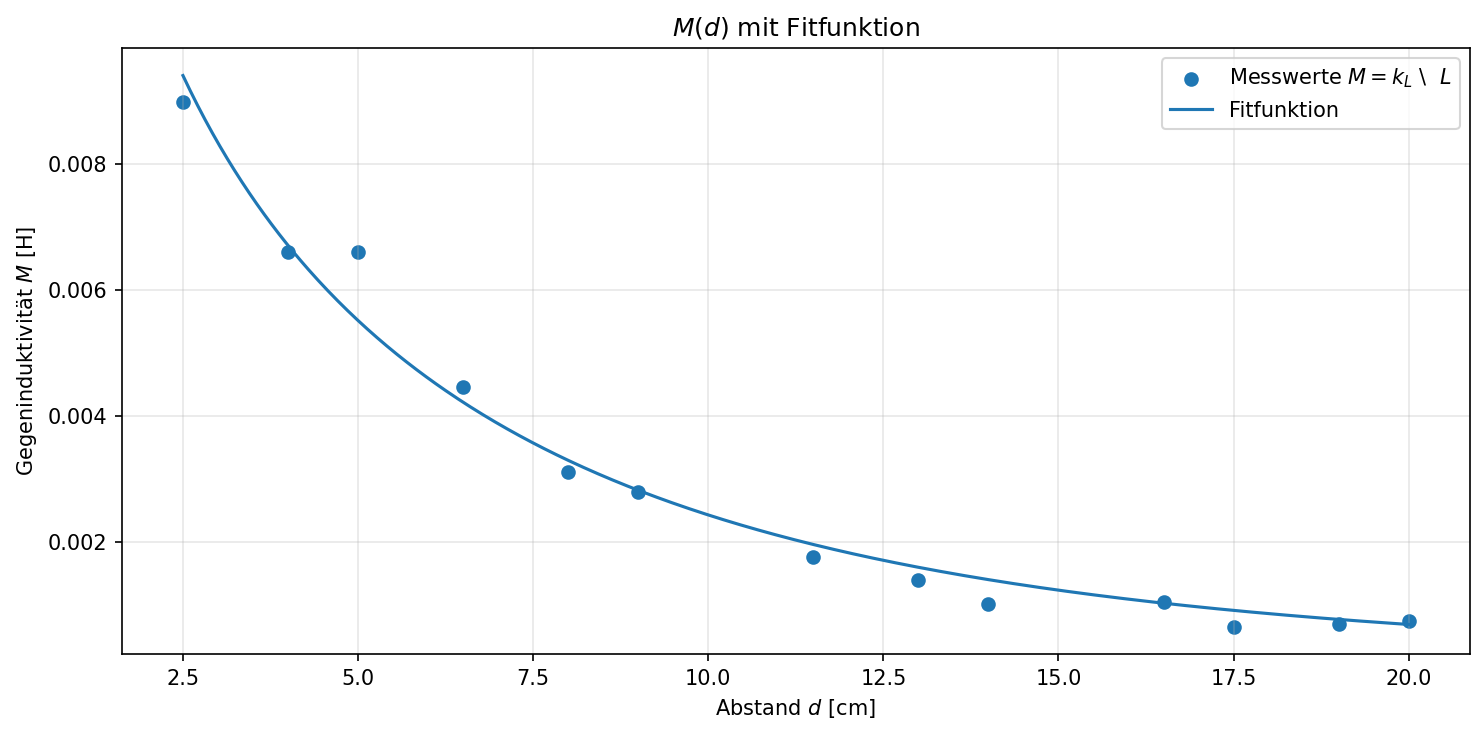

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import ellipk, ellipe

# =========================================================
# 1) EINGABE: Peaks (Aufgabe 3)
# =========================================================
data = [
    (2.5,  2.384186, 3.767014),
    (4.0,  2.479553, 3.433228),
    (5.0,  2.479553, 3.433228),
    (6.5,  2.574921, 3.194809),
    (8.0,  2.670288, 3.099442),
    (9.0,  2.670288, 3.051758),
    (11.5, 2.717972, 2.956390),
    (13.0, 2.765656, 2.956390),
    (14.0, 2.765656, 2.901984),
    (16.5, 2.765656, 2.906540),
    (17.5, 2.813339, 2.902760),
    (19.0, 2.813339, 2.908210),
    (20.0, 2.813339, 2.914901),
]
df = pd.DataFrame(data, columns=["d_cm", "f1_kHz", "f2_kHz"])

# Ungekoppelte Eigenfrequenz
f0_kHz = 2.843

# Kapazität aus dem Aufbau eintragen (sonst bleibt M(d) unbestimmt)
# Beispiel: 100 nF -> 100e-9
C_F = 149.393698e-9  # <-- HIER setzen, wenn du M(d) wirklich plotten willst

# =========================================================
# 2) k_L aus Peaks
# =========================================================
f_plus = np.minimum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))
f_minus = np.maximum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))

kL = (f_minus**2 - f_plus**2) / (f_minus**2 + f_plus**2)
df["kL"] = kL

# =========================================================
# 3) L und M(d) (nur wenn C_F gesetzt)
# =========================================================
if C_F is None:
    raise ValueError("Bitte C_F (Kapazität aus dem Aufbau) setzen, damit M(d) berechnet und gefittet werden kann.")

f0_Hz = f0_kHz * 1e3
L_H = 1.0 / ((2.0 * np.pi * f0_Hz) ** 2 * C_F)

M_meas = kL * L_H  # M(d) = kL(d)*L

# =========================================================
# 4) Maxwell-Modell: M(d) = scale * M_ring(d,a)
# =========================================================
mu0 = 4.0 * np.pi * 1e-7

def M_ring(d_m, a_m):
    kappa = 1.0 / np.sqrt(1.0 + (d_m / (2.0 * a_m))**2)
    m = kappa**2
    K = ellipk(m)
    E = ellipe(m)
    return 2.0 * mu0 * a_m / kappa * ((1.0 - 0.5 * kappa**2) * K - E)

def M_model(d_m, scale, a_m):
    return scale * M_ring(d_m, a_m)

d_m = df["d_cm"].to_numpy(float) / 100.0

# Startwerte: scale ~ 1, a ~ 8 cm
p0 = [1.0, 0.08]
bounds = ([0.0, 1e-4], [np.inf, 1.0])

popt, _ = curve_fit(M_model, d_m, M_meas, p0=p0, bounds=bounds, maxfev=20000)
scale_fit, a_fit = popt

# =========================================================
# 5) Plot (nur Grafik, keine Tabellen-Prints)
# =========================================================
d_plot = np.linspace(d_m.min(), d_m.max(), 500)
M_plot = M_model(d_plot, *popt)

plt.figure(figsize=(10, 5), dpi=150)
plt.scatter(df["d_cm"], M_meas, label="Messwerte $M=k_L$ \\  $L$")
plt.plot(d_plot * 100.0, M_plot, label=f"Fitfunktion")
plt.xlabel("Abstand $d$ [cm]")
plt.ylabel("Gegeninduktivität $M$ [H]")
plt.title("$M(d)$ mit Fitfunktion")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

